In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dplus = pd.read_csv('data/disney_plus.csv', index_col = 0)

In [3]:
dplus

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,A Spark Story,"Jason Sterman, Leanne Dare","Apthon Corbin, Louis Gonzales",NaN,"September 24, 2021",2021,TV-PG,88 min,Documentary,Two Pixar filmmakers strive to bring their uni...
s2,Movie,Spooky Buddies,Robert Vince,"Tucker Albrizzi, Diedrich Bader, Ameko Eks Mas...","United States, Canada","September 24, 2021",2011,G,93 min,"Comedy, Fantasy, Kids",The puppies go on a spooky adventure through a...
s3,Movie,The Fault in Our Stars,Josh Boone,"Shailene Woodley, Ansel Elgort, Laura Dern, Sa...",United States,"September 24, 2021",2014,PG-13,127 min,"Coming of Age, Drama, Romance",Hazel and Gus share a love that sweeps them on...
s4,TV Show,Dog: Impossible,NaN,Matt Beisner,United States,"September 22, 2021",2019,TV-PG,2 Seasons,"Animals & Nature, Docuseries, Family",Matt Beisner uses unique approaches to modifyi...
s5,TV Show,Spidey And His Amazing Friends,NaN,"Benjamin Valic, Lily Sanfelippo, Jakari Fraser...",United States,"September 22, 2021",2021,TV-Y,1 Season,"Action-Adventure, Animation, Kids",Spidey teams up with pals to become The Spidey...
...,...,...,...,...,...,...,...,...,...,...,...
s1364,Movie,The Sword in the Stone,Wolfgang Reitherman,"Sebastian Cabot, Karl Swenson, Rickie Sorensen...",United States,"October 1, 2019",1963,G,80 min,"Action-Adventure, Animation, Comedy",Merlin trains a young orphan who's destined to...
s1365,Movie,Those Calloways,Norman Tokar,"Brian Keith, Vera Miles, Brandon de Wilde, Wal...",United States,"October 1, 2019",1965,PG,132 min,"Animals & Nature, Drama, Family",A strong-willed family struggles to establish ...
s1366,TV Show,Disney Kirby Buckets,NaN,"Jacob Bertrand, Mekai Curtis, Cade Sutton, Oli...",United States,NaN,2014,TV-Y7,3 Seasons,"Action-Adventure, Comedy, Coming of Age",Welcome to Kirby's world! It's rude and sketchy.


In [4]:
print(dplus.dtypes)

type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


## 1
Create a dataframe titled `movie_ratings` that contains the ratings (G, PG, TV-G, etc) and how many of those movies exist in the dataframe.

In [5]:
movie_ratings = dplus['rating'].value_counts()

In [18]:
movie_ratings

rating
TV-G        307
TV-PG       275
G           235
PG          227
TV-Y7       130
TV-14        72
PG-13        60
TV-Y         48
TV-Y7-FV     12
Name: count, dtype: int64

## 2
Using the `movie_ratings` dataframe, create a **bar chart** that displays the count of the top 5 movie ratings.
> 💡 *Hint: Use `.plot.bar()` with `x='rating'` and `y='count'`. Don't forget to add a title and axis label!*

Text(0.5, 1.0, 'Top 5 Movie Ratings')

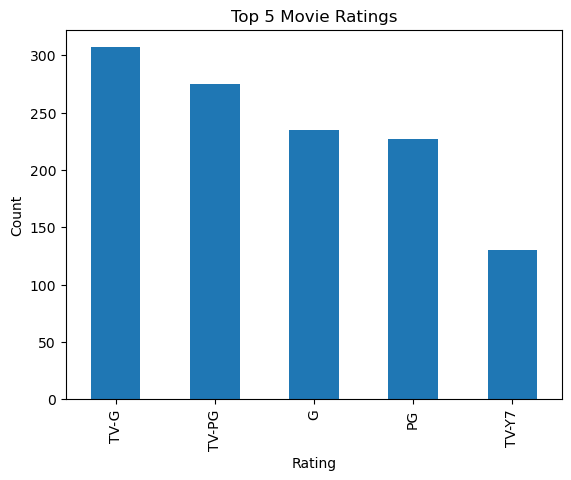

In [7]:
movie_ratings.nlargest(5).plot.bar()

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Top 5 Movie Ratings')

## 3
Using `movies_df`, subset the data to create a new dataframe named **`year_duration`** that contains only two columns:
- `release_year`
- `duration`

In [8]:
year_duration = dplus[['release_year', 'duration']]

In [9]:
year_duration

,release_year,duration
show_id,,
s1,2021,88 min
s2,2011,93 min
s3,2014,127 min
s4,2019,2 Seasons
s5,2021,1 Season
...,...,...
s1364,1963,80 min
s1365,1965,132 min
s1366,2014,3 Seasons


## 4
Using your `year_duration` dataframe, filter for movies released between **1975 and 1984** (inclusive) and find the:
- **Minimum** duration
- **Maximum** duration
- **Average** duration

In [10]:
dur_time = year_duration[~year_duration['duration'].astype(str).str.contains('Season', na=False)]

In [11]:
dur_time

,release_year,duration
show_id,,
s1,2021,88 min
s2,2011,93 min
s3,2014,127 min
s7,2009,106 min
s8,2021,22 min
...,...,...
s1360,2001,73 min
s1362,1978,104 min
s1363,1986,75 min


In [17]:
dur_time['duration'] = dur_time['duration'].str[:-4].astype(int)

ValueError: invalid literal for int() with base 10: ''

In [13]:
year_duration.loc[(year_duration.release_year >= 1975) & (year_duration.release_year <= 1984)].describe()

,release_year
count,38.000000
mean,1979.000000
std,2.818855
min,1975.000000
25%,1977.000000
50%,1979.000000
75%,1981.000000
max,1984.000000


## 5
Using the `year_duration` dataframe, create a **scatterplot** that shows movie durations over the years. Add a descriptive title to your chart.
After creating your plot, answer the following in a comment or markdown cell:
> *Do you notice any correlation between release year and movie duration?*

Text(0.5, 1.0, 'Movie Durations over Time')

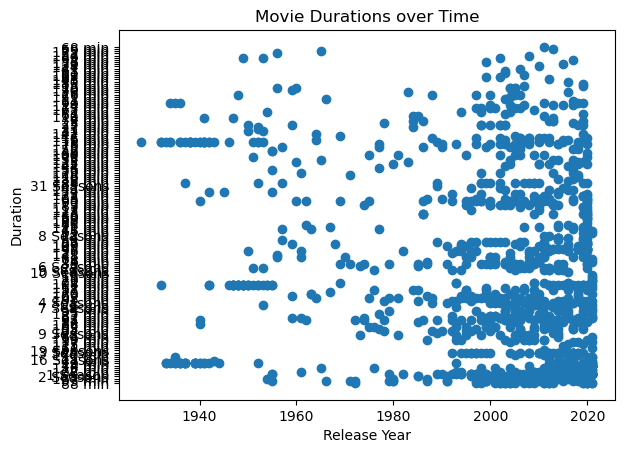

In [14]:
plt.scatter(year_duration.release_year, year_duration.duration)
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Movie Durations over Time")

## 6
Find the **actual correlation value** between `release_year` and `duration`.
> 💡 *Hint: Use `.corr()` on the `year_duration` dataframe.*
Answer the following in a comment or markdown cell:
> *Based on the correlation value, is there a meaningful correlation between release year and duration?*

## 7
Using `movies_df`, find which **year had the most G-rated movie releases**.
> 🎯 *Challenge: Can you accomplish this in a single line of code?*

In [15]:
g_rated_movies = dplus[dplus['rating'] == 'G']

year_counts = g_rated_movies.groupby('release_year').size()

best_year = year_counts.idxmax()
max_releases = year_counts.max()

print(f"The year with the most G-rated movie releases is {best_year} with {max_releases} releases.")

The year with the most G-rated movie releases is 2003 with 12 releases.


## 8
1. Find which **year had the most total movie releases**.
2. Create a new dataframe containing only movies from that year.
3. Convert the `duration` column to integers.
4. Use the **IQR method** to determine the upper and lower cutoffs for outliers.
5. Calculate what **percentage of movies** from that year had durations that were statistical outliers.
> 💡 *Hint: Outlier cutoffs are defined as:*
> - *Lower cutoff: Q1 − (1.5 × IQR)*
> - *Upper cutoff: Q3 + (1.5 × IQR)*

In [25]:
top_year = dplus['release_year'].value_counts().idxmax()

In [26]:
print(top_year)

2020


In [30]:
top_year_movies = dplus[dplus['release_year'] == 2020].copy()

In [32]:
top_year_movies

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s11,Movie,Jade Eyed Leopard,NaN,Jeremy Irons,NaN,"September 17, 2021",2020,TV-PG,44 min,"Animals & Nature, Documentary","Jade Eyed Leopard follows a leopard, Toto, thr..."
s22,TV Show,"Mira, Royal Detective",NaN,"Leela Ladnier, Utkarsh Ambudkar, Roshni Edward...",United States,"September 8, 2021",2020,TV-Y,2 Seasons,"Animation, Fantasy, Kids",Mira is the new royal detective in the land of...
s37,TV Show,Life Below Zero: Next Generation,NaN,Mocean Melvin,United States,"August 25, 2021",2020,TV-14,2 Seasons,"Action-Adventure, Animals & Nature, Docuseries",The next generation of Alaskans struggle to su...
s55,TV Show,Walt Disney Animation Studios: Short Circuit E...,NaN,NaN,NaN,"August 4, 2021",2020,PG,2 Seasons,"Animation, Anthology, Family",Welcome to Short Circuit - an experimental sho...
s59,TV Show,Critter Fixers: Country Vets,NaN,Sullivan Jones,United States,"July 28, 2021",2020,TV-14,2 Seasons,"Animals & Nature, Docuseries, Family",Dr. Hodges and Dr. Ferguson own and operate a ...
...,...,...,...,...,...,...,...,...,...,...,...
s557,Movie,Lamp Life,Valerie LaPointe,"Annie Potts, Jim Hanks, Ally Maki, Emily Davis",United States,"January 31, 2020",2020,TV-G,11 min,"Animation, Comedy, Family",Lamp Life answers the question of what happene...
s559,TV Show,Diary of a Future President,NaN,"Tess Romero, Selenis Leyva, Charlie Bushnell, ...",United States,"January 17, 2020",2020,TV-PG,2 Seasons,"Comedy, Coming of Age, Family",Elena Cañero-Reed will one day become the U.S....
s568,Movie,Forky Asks a Question: What is Reading?,Bob Peterson,"Tony Hale, Addison Andrews, Mila Crespo, Imani...",United States,"January 10, 2020",2020,TV-G,7 min,"Animation, Comedy, Family",The energetic Peas-n-a-Pod siblings teach Fork...


In [33]:
top_year_movies['duration'] = top_year_movies['duration'].str.extract('(/d+)').astype(int)

ValueError: cannot convert float NaN to integer

## 9
Add a new column called **`length_category`** to `movies_df` that categorizes each movie as one of the following:

| Category  | Duration               |
|-----------|------------------------|
| `short`   | 30 minutes or less     |
| `average` | Between 31–120 minutes |
| `long`    | More than 120 minutes  |

**Bonus:** Once the column is created, create a **pie chart** showing the distribution of movie length categories.

In [ ]:
dplus['length_category'] = [

## 10
1. Create a new column called **`gap`** that calculates the difference between the year a movie was added to Disney+ and its original `release_year`.
2. Find the **movie with the greatest gap**.
3. Find the **average gap** across all movies.